# Investigating AI Fairness & Bias: Hands-On Analysis with the Adult Dataset

**Purpose**  
This notebook helps students see how machine learning models can learn patterns that look useful technically but still produce unfair outcomes across groups.

**What students will do**
- train a baseline model
- compare performance across groups
- look for proxy variables
- test counterfactual “what if” changes
- explore threshold trade-offs

**Discussion format**
- work in small teams
- share observations, questions, and disagreements
- keep the focus on evidence, not on finding one “correct” answer

## Warm-up discussion

Before the code, spend a few minutes on a fairness story:

- Two people have the same qualifications.
- One gets a positive outcome, the other does not.
- Ask: what could explain the difference?
- Ask: what hidden features might act as proxies?

The goal is to get comfortable with uncertainty, trade-offs, and group discussion before looking at the data.

## Before you start: the key ideas in plain language

- **Proxy**: a feature that indirectly reveals something sensitive.
- **Counterfactual**: a “what if” change where only one feature is altered.
- **Group fairness**: comparing outcomes across groups.
- **Individual fairness**: similar people should receive similar treatment.
- **Threshold**: the cutoff that turns a probability into a yes/no decision.

You do not need to memorize the definitions now. The notebook will keep returning to them in context.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

def build_forest_pipeline(reference_frame: pd.DataFrame) -> Pipeline:
    """Create a model pipeline that handles numeric and categorical columns."""
    numeric_cols = reference_frame.select_dtypes(exclude=["object", "category"]).columns.tolist()
    categorical_cols = reference_frame.select_dtypes(include=["object", "category"]).columns.tolist()

    preprocess = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ],
        remainder="drop",
    )

    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]
    )

def subgroup_metrics(y_true, y_pred, group_series, feature_name: str) -> pd.DataFrame:
    rows = []
    for group_value in group_series.dropna().unique():
        idx = group_series == group_value
        rows.append({
            "Feature": feature_name,
            "Group": group_value,
            "Accuracy": accuracy_score(y_true[idx], y_pred[idx]),
            "Precision": precision_score(y_true[idx], y_pred[idx], zero_division=0),
            "Recall": recall_score(y_true[idx], y_pred[idx], zero_division=0),
            "F1": f1_score(y_true[idx], y_pred[idx], zero_division=0),
            "N": int(idx.sum()),
        })
    return pd.DataFrame(rows)

def flip_sex(value):
    mapping = {"Male": "Female", "Female": "Male"}
    return mapping.get(value, value)

## 1) Load the Adult dataset

The target is whether a person earns more than \$50K per year.

A few notes for students:
- the dataset comes from the US Census
- `fnlwgt` is a survey weight
- `?` means missing information and is removed here for simplicity
- the notebook uses a small subsample so the analysis runs quickly in class

In [15]:
data = fetch_openml(name="adult", version=2, as_frame=True)
df = data.frame.copy()

print("Original shape:", df.shape)
df.replace("?", np.nan, inplace=True)
print("\nMissing values before dropping rows:")
print(df.isna().sum()[df.isna().sum() > 0])

df = df.dropna().reset_index(drop=True)
print("\nShape after dropping missing rows:", df.shape)

target = "class"
sensitive_features = ["sex", "race"]

# Small, stratified sample for classroom speed and readability
df_small, _ = train_test_split(
    df,
    train_size=500,
    stratify=df[target],
    random_state=RANDOM_STATE,
)
df_small= df
X = df_small.drop(columns=[target])
y = (df_small[target] == ">50K").astype(int)

print("\nSubsample shape:", X.shape)
print("Positive rate:", round(y.mean(), 3))

Original shape: (48842, 15)

Missing values before dropping rows:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Shape after dropping missing rows: (45222, 15)

Subsample shape: (45222, 14)
Positive rate: 0.248


## 2) Train a baseline classifier

We start with a Random Forest so students can focus on the fairness ideas first.

The main question is not only “How accurate is the model?” but also:
- who does it work well for?
- who gets treated differently?
- does overall accuracy hide group-level gaps?

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

baseline_model = build_forest_pipeline(X_train)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print(f"Baseline accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Baseline precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Baseline recall: {recall_score(y_test, y_pred, zero_division=0):.3f}")

Baseline accuracy: 0.847
Baseline precision: 0.725
Baseline recall: 0.616


## 3) Compare performance across groups

Now we ask the model a fairness question:

- does performance differ for men and women?
- does performance differ across racial groups?

The goal is not to jump to conclusions from one number, but to look for patterns that deserve discussion.

In [17]:
metrics_sex = subgroup_metrics(y_test, y_pred, X_test["sex"], "sex")
metrics_race = subgroup_metrics(y_test, y_pred, X_test["race"], "race")
metrics_df = pd.concat([metrics_sex, metrics_race], ignore_index=True)

metrics_df.sort_values(["Feature", "Group"]).reset_index(drop=True)

,Feature,Group,Accuracy,Precision,Recall,F1,N
0,race,Amer-Indian-Eskimo,0.900000,0.666667,0.615385,0.640000,90
1,race,Asian-Pac-Islander,0.852713,0.742857,0.722222,0.732394,258
2,race,Black,0.914081,0.746835,0.531532,0.621053,838
3,race,Other,0.887500,0.500000,0.333333,0.400000,80
4,race,White,0.838668,0.724971,0.618557,0.667550,7779
5,sex,Female,0.921179,0.771429,0.520661,0.621711,2918
6,sex,Male,0.811817,0.718675,0.634912,0.674202,6127


## 4) Look for proxy variables

Even if we remove `sex` and `race`, the model may still infer them from other columns.

That matters because a model can behave as if it “knows” sensitive information without ever using the sensitive column directly.

In [18]:
proxy_X_train = X_train.drop(columns=sensitive_features)
proxy_X_test = X_test.drop(columns=sensitive_features)

# Predict sex from the remaining features
sex_encoder = LabelEncoder()
y_sex_train = sex_encoder.fit_transform(X_train["sex"])
y_sex_test = sex_encoder.transform(X_test["sex"])

proxy_sex_model = build_forest_pipeline(proxy_X_train)
proxy_sex_model.fit(proxy_X_train, y_sex_train)
sex_pred = proxy_sex_model.predict(proxy_X_test)

# Predict race from the remaining features
race_encoder = LabelEncoder()
y_race_train = race_encoder.fit_transform(X_train["race"])
y_race_test = race_encoder.transform(X_test["race"])

proxy_race_model = build_forest_pipeline(proxy_X_train)
proxy_race_model.fit(proxy_X_train, y_race_train)
race_pred = proxy_race_model.predict(proxy_X_test)

print(f"Accuracy predicting sex from other features:  {accuracy_score(y_sex_test, sex_pred):.3f}")
print(f"Accuracy predicting race from other features: {accuracy_score(y_race_test, race_pred):.3f}")

Accuracy predicting sex from other features:  0.849
Accuracy predicting race from other features: 0.874


### Which features look most proxy-like?

Permutation importance gives a simple way to ask which columns matter most for each proxy model.

Students can use this result as a discussion starter:
- which features may indirectly reveal sensitive information?
- are the strongest predictors plausible, surprising, or both?

In [19]:
sex_perm = permutation_importance(
    proxy_sex_model,
    proxy_X_test,
    y_sex_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

race_perm = permutation_importance(
    proxy_race_model,
    proxy_X_test,
    y_race_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

sex_importance = pd.Series(sex_perm.importances_mean, index=proxy_X_test.columns).sort_values(ascending=False)
race_importance = pd.Series(race_perm.importances_mean, index=proxy_X_test.columns).sort_values(ascending=False)

proxy_table = pd.DataFrame({
    "Top features for sex proxy": sex_importance.head(8).index,
    "Top features for race proxy": race_importance.head(8).index,
})

proxy_table

,Top features for sex proxy,Top features for race proxy
0,relationship,native-country
1,occupation,fnlwgt
2,marital-status,hours-per-week
3,hours-per-week,relationship
4,workclass,age
5,age,capital-gain
6,fnlwgt,marital-status
7,native-country,capital-loss


## 5) Counterfactual analysis: a simple sex-swap test

Now we ask a more concrete “what if” question:

- keep the person the same
- change only `sex`
- see how the predicted income probability changes

This does not prove what is “true” in the real world.  
It is a model stress test that helps students see whether the prediction is sensitive to a protected attribute.

In [20]:
sample = X_test.sample(12, random_state=RANDOM_STATE).copy()
sample_flipped = sample.copy()
sample_flipped["sex"] = sample_flipped["sex"].map(flip_sex)

orig_prob = baseline_model.predict_proba(sample)[:, 1]
flip_prob = baseline_model.predict_proba(sample_flipped)[:, 1]

counterfactual_df = pd.DataFrame({
    "Original sex": sample["sex"].values,
    "Flipped sex": sample_flipped["sex"].values,
    "Pred. prob. original": orig_prob,
    "Pred. prob. flipped": flip_prob,
    "Delta (flipped - original)": flip_prob - orig_prob,
})

counterfactual_df.sort_values("Delta (flipped - original)", ascending=False)

,Original sex,Flipped sex,Pred. prob. original,Pred. prob. flipped,Delta (flipped - original)
4,Male,Female,0.600,0.675,0.075
10,Male,Female,0.005,0.040,0.035
7,Female,Male,0.000,0.015,0.015
3,Female,Male,0.000,0.005,0.005
1,Female,Male,0.000,0.000,0.000
6,Male,Female,0.000,0.000,0.000
11,Male,Female,0.270,0.265,-0.005
2,Male,Female,0.105,0.095,-0.010
9,Male,Female,0.785,0.700,-0.085
0,Female,Male,0.900,0.790,-0.110


## 6) Threshold sensitivity

A model produces probabilities, but a decision rule needs a cutoff.

- lower threshold: more positive predictions, usually higher recall
- higher threshold: fewer positive predictions, usually higher precision

Here we compare thresholds for **men and women only** to keep the classroom view simple.

In [21]:
thresholds = [0.3, 0.5, 0.7]
threshold_rows = []

for threshold in thresholds:
    pred_threshold = (y_prob >= threshold).astype(int)
    for sex_value in ["Male", "Female"]:
        idx = X_test["sex"] == sex_value
        threshold_rows.append({
            "Threshold": threshold,
            "Sex": sex_value,
            "Precision": precision_score(y_test[idx], pred_threshold[idx], zero_division=0),
            "Recall": recall_score(y_test[idx], pred_threshold[idx], zero_division=0),
        })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,Threshold,Sex,Precision,Recall
0,0.3,Male,0.610156,0.812134
1,0.3,Female,0.635000,0.699725
2,0.5,Male,0.715821,0.638105
3,0.5,Female,0.772358,0.523416
4,0.7,Male,0.830946,0.463012
5,0.7,Female,0.856209,0.360882


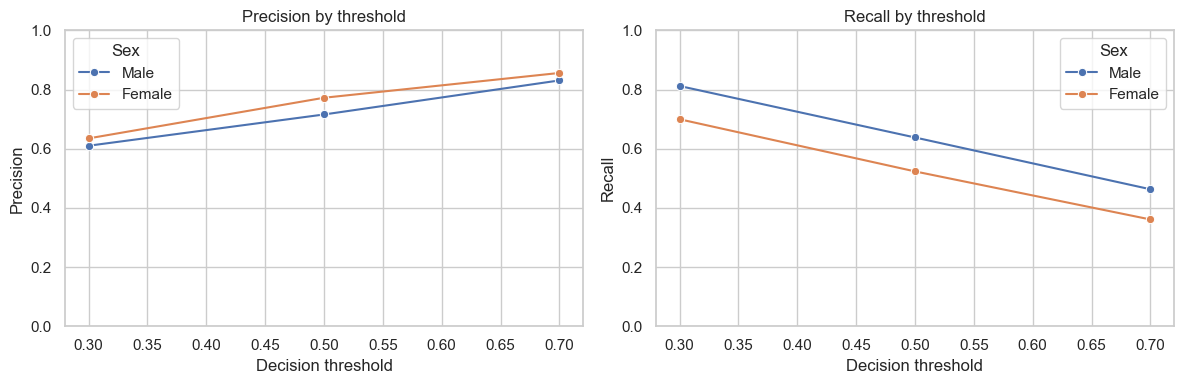

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(
    data=threshold_df,
    x="Threshold",
    y="Precision",
    hue="Sex",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Precision by threshold")
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=threshold_df,
    x="Threshold",
    y="Recall",
    hue="Sex",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Recall by threshold")
axes[1].set_ylim(0, 1)

for ax in axes:
    ax.set_xlabel("Decision threshold")
    ax.legend(title="Sex")

plt.tight_layout()
plt.show()

## 7) Predicted probabilities for actual positives

This view is useful when the model looks fine overall but still behaves unevenly on people who truly belong to the positive class.

It helps students ask:
- are some groups assigned lower confidence?
- could that matter once a threshold is applied?

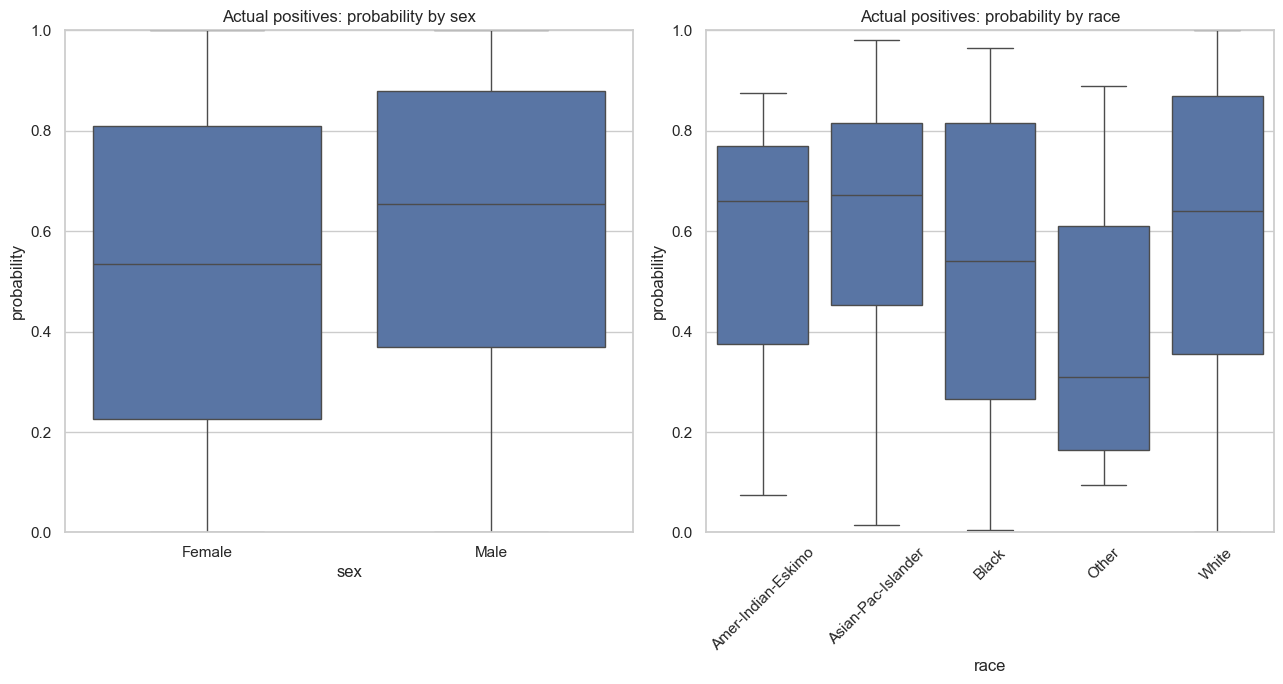

In [25]:
positive_mask = y_test == 1
positive_view = pd.DataFrame({
    "probability": y_prob[positive_mask],
    "sex": X_test.loc[positive_mask, "sex"],
    "race": X_test.loc[positive_mask, "race"],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

sns.boxplot(data=positive_view, x="sex", y="probability", ax=axes[0])
axes[0].set_title("Actual positives: probability by sex")
axes[0].set_ylim(0, 1)

sns.boxplot(data=positive_view, x="race", y="probability", ax=axes[1])
axes[1].set_title("Actual positives: probability by race")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 8) What you should discuss after the notebook

Use these questions as a structured debrief:

1. Which results were easy to explain, and which were surprising?
2. Which features looked like proxies?
3. Which fairness idea felt most relevant here: group fairness, individual fairness, or counterfactual fairness?
4. Where did the model seem to be most sensitive to threshold changes?
5. What would you change first if this model were used in a real decision process?

## 9) Glossary

This is the “keep the philosophy at the end” section.

There is no single universal definition of fairness.  
The right choice depends on the problem, the people affected, and the trade-offs a system makes.

| Term | Simple meaning | Why it matters here |
|---|---|---|
| Proxy | A feature that indirectly reveals a sensitive attribute | A model can use hidden clues even when sensitive fields are removed |
| Counterfactual | A “what if” change to one feature | Helps test whether predictions shift in a way that feels unjustified |
| Group fairness | Comparing outcomes across groups | Useful when we want to spot systematic gaps |
| Individual fairness | Similar people should be treated similarly | Useful when the same person changes only slightly |
| Demographic parity | Groups receive similar positive rates | A simple group-level target, but not always appropriate |
| Equal opportunity | Qualified people should have similar chances | Focuses on the people who should have been helped |
| Threshold | The cutoff used to make a yes/no decision | Small changes here can create big fairness differences |
| Trade-off | Improving one fairness goal may worsen another | Real systems rarely satisfy every fairness goal at once |

The main philosophical point is simple: fairness is not a single formula. It is a choice we make in context.

## 10) Transfer the ideas to other datasets

For your project:

### Group task
For your dataset, answer these questions:
1. Which columns should be treated as group labels?
2. Which columns might act as proxies?
3. What counterfactual change would you test?
4. How might the decision threshold affect different groups?

Aim for a short team summary, not a perfect answer.